# 样章 · 从变化率进入微分方程

## 学习目标与先修知识

完成后，你能把导数（derivative）、定积分（definite integral）与初值问题（initial value problem）联系起来，推导恒定输入的解析解（analytical solution），并检查零清除情形。

**先修知识**：[平衡、负反馈与参数变化](03-equilibrium-feedback.ipynb)中的平衡（equilibrium）与递推；所需微积分在本节引入。


## 具体问题

我们已经用一个小区间的收支（mass balance）近似连续变化。把区间不断缩短，能否直接描述“此刻的变化快慢”？
本节先从一个已知函数 A(t) = 2(1 − exp(−0.5t)) 观察变化率，随后说明它为何是模型的解。

## 初步实验

固定起点 t = 2 T，比较跨越不同长度区间的平均变化率。
`np.exp(x)` 表示指数函数（exponential function） eˣ，其中 e 约为 2.71828。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
from systems_science.theme import DATA_COLORS, SERIES_COLORS

plot_style()

In [2]:
def trial_curve(t):
    return 2 * (1 - np.exp(-0.5 * t))

widths = [0.8, 0.4, 0.2, 0.1]
secants = [(trial_curve(2 + width) - trial_curve(2)) / width for width in widths]
display(Markdown(show_table(["区间宽度 / T", "平均变化率 / (U/T)"], zip(widths, secants))))

| 区间宽度 / T | 平均变化率 / (U/T) |
| --- | --- |
| 0.8 | 0.303206 |
| 0.4 | 0.333426 |
| 0.2 | 0.350084 |
| 0.1 | 0.358834 |

## 模型假设

把研究对象看成一个**充分混合的单室模型（one-compartment model）**：用一个数描述室内示踪物质（tracer）总量。
示踪物质只是便于思考的标记物。本单元使用人工单位 U 与 T，参数（parameter）是教学选择，
不对应具体药物、患者或真实生理测量。边界外的输入被视为已知；不讨论组织容积、
浓度（concentration）、多室交换或观测噪声。A 是物质量，不是浓度。

| 量 | 含义 | 单位与条件 |
|---|---|---|
| $t$ | 从实验起点经过的时间 | T，$t\geq0$ |
| $A$、$A_0$ | 当前与初始物质量 | U，连续模型非负 |
| $u$ | 流入速率 | U/T，非负 |
| $k$ | 比例清除系数（elimination rate constant） | 1/T，非负 |
| $h$ | 计算时间步长（time step） | T，正数 |

假设清除速率为 $kA$，单位是 U/T。这个比例关系是一项建模假设，
不代表所有物质在任意条件下都按同一机制清除。

## 数学解释与推导

### 1. 从平均变化率到导数

在 $t$ 到 $t+h$ 之间，平均变化率是 $[A(t+h)-A(t)]/h$。
令 h 逐渐趋向零，若这个比值趋向某个确定数，就把它叫作 t 时刻的导数：

$$A'(t)=\frac{dA}{dt}=\lim_{h\to0}\frac{A(t+h)-A(t)}h.$$

符号 lim 表示“越来越靠近”，不是直接拿零去作除数。图上的对应量是切线（tangent line）斜率（slope），单位仍是 U/T。
本单元用到的求导规则只有：常数的导数为零，和的导数逐项相加，
$d(ct)/dt=c$，以及 $d(e^{ct})/dt=ce^{ct}$。
最后一式来自 $e^{c(t+h)}=e^{ct}e^{ch}$ 和 $\lim_{z\to0}(e^z-1)/z=1$；
当 $z=ch$，差商（difference quotient）极限（limit）便多出系数 c。

### 2. 从累积量到积分

令 q(t) 为净流率，把时间分成很多小区间，每一段净进入的量近似为 q(tₙ)h。
当区间越来越细，这些小量的和趋向定积分：

$$\int_0^t q(s)\,ds=\lim_{h\to0}\sum_n q(t_n)h.$$

s 是求和过程中用的时间变量，ds 对应越来越短的时间片。积分单位是 (U/T) × T = U。
图中它是带符号的面积：负流率对应负的净累积。对本节连续的流率函数，
“累积量的导数等于流率”，于是

$$A(t)-A_0=\int_0^t[u-kA(s)]\,ds.$$

这就是收支的连续版本。积分和导数在这里分别回答“累计多少”和“此刻多快”。

### 3. 微分方程与初值

把连续收支写成瞬时变化率：$A'=u-kA$。它是一阶常微分方程（ordinary differential equation，ODE）：
未知对象是整条函数 A(t)，方程涉及它的一阶导数。加上 $A(0)=A_0$ 才确定本次实验从哪里开始。
同一个方程、不同的初值（initial condition），给出不同轨迹。

### 4. 推导恒定输入的解

当 $k>0$ 且 u 恒定，令 $B(t)=A(t)-u/k$，即离开平衡的偏差。平衡是常数，故

$$B'=A'=u-k(B+u/k)=-kB.$$

指数函数的变化率正比于自身，所以取 $B(t)=Ce^{-kt}$，代入便满足方程。
初值给出 $C=A_0-u/k$。还原 A，得到

$$A(t)=\frac uk+\left(A_0-\frac uk\right)e^{-kt}
=A_0e^{-kt}+\frac uk(1-e^{-kt}).$$

它同时满足初值和方程；正 k 使指数偏差消退，时间尺度（time scale） $1/k$ 的单位是 T。
无流入时只有衰减项；当 k = 0，方程改为 A′ = u，解为 $A=A_0+ut$，需要单独处理。
本式是理想模型的精确解，并不是对真实生理系统的精确描述。

## 核心实现

公式中的 `1 − exp(−kt)` 在 kt 很小时会丢失有效数字。
`np.expm1(x)` 直接计算 exp(x) − 1，让这个差保持精度；它没有改变模型。

In [3]:
def exact_amount(t, u=1.0, k=0.5, A0=0.0):
    """恒定输入解析解，显式处理零清除与很小的 k。"""
    t = np.asarray(t, dtype=float)
    if not np.all(np.isfinite(t)) or np.any(t < 0):
        raise ValueError("时间必须有限且非负")
    if not all(np.isfinite(v) and v >= 0 for v in (u, k, A0)):
        raise ValueError("模型参数必须有限且非负")
    if k == 0:
        return A0 + u * t
    # expm1(x) 计算 exp(x)-1，避免小 x 时两个接近的数相减。
    return A0 * np.exp(-k * t) + u * (-np.expm1(-k * t) / k)

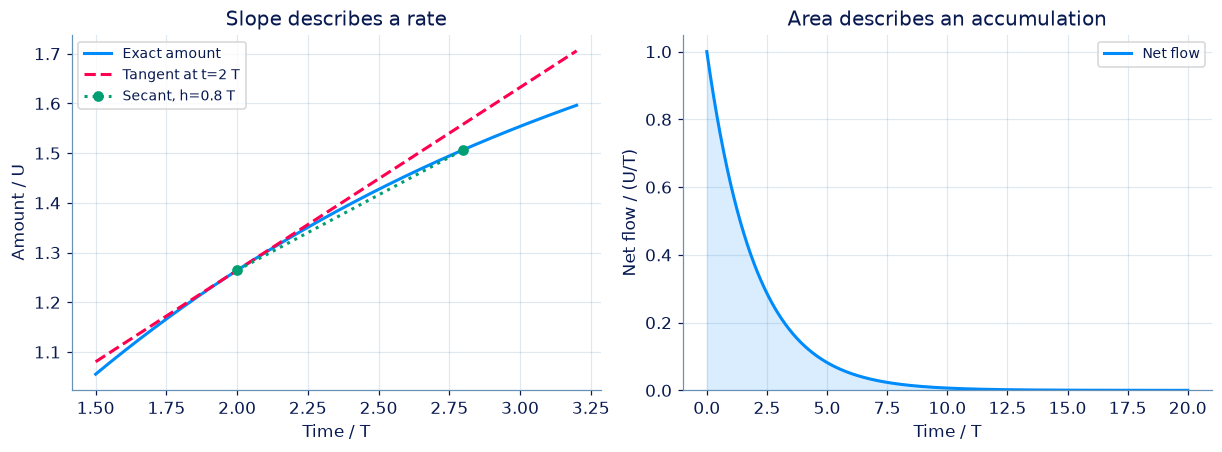

净流量面积约 1.999913 U，存量变化 1.999909 U


In [4]:
t = np.linspace(0, 20, 2001)
a = exact_amount(t)
net_flow = 1 - 0.5 * a
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
zoom = np.linspace(1.5, 3.2, 300)
axes[0].plot(zoom, exact_amount(zoom), label="Exact amount")
slope = 1 - 0.5 * exact_amount(2)
axes[0].plot(zoom, exact_amount(2) + slope*(zoom-2), "--", label="Tangent at t=2 T")
axes[0].plot([2, 2.8], [exact_amount(2), exact_amount(2.8)], ":o", label="Secant, h=0.8 T")
axes[0].set(xlabel="Time / T", ylabel="Amount / U", title="Slope describes a rate")
axes[1].plot(t, net_flow, label="Net flow")
axes[1].fill_between(t, 0, net_flow, alpha=0.15)
axes[1].set(xlabel="Time / T", ylabel="Net flow / (U/T)", title="Area describes an accumulation", ylim=(0, 1.05))
for ax in axes: ax.legend(fontsize=9)
plt.show()
integrated_flow = np.trapezoid(net_flow, t)
assert abs(integrated_flow - (a[-1] - a[0])) < 1e-5
print(f"净流量面积约 {integrated_flow:.6f} U，存量变化 {a[-1]-a[0]:.6f} U")

## 对照实验

用中心差分（central difference）独立检查解析解的导数：在 t 左右各取一个很小时间间隔。
检查初值、一般情况、无输入、零清除、完全无流动、平衡初值以及极小清除系数。
有限差分（finite difference）与积分都是近似检查，不替代上面的代数推导。

In [5]:
cases = [(1, 0.5, 0), (0, 0.5, 3), (1, 0, 2), (0, 0, 2), (1, 0.5, 2), (1, 1e-12, 2)]
checks = []
for input_rate, clearance, initial in cases:
    assert np.isclose(exact_amount(0, input_rate, clearance, initial), initial)
    probe, epsilon = 2.0, 1e-4
    finite_rate = (exact_amount(probe+epsilon, input_rate, clearance, initial)
                   - exact_amount(probe-epsilon, input_rate, clearance, initial)) / (2*epsilon)
    model_rate = input_rate - clearance * exact_amount(probe, input_rate, clearance, initial)
    assert np.isclose(finite_rate, model_rate, atol=1e-8, rtol=1e-7)
    checks.append([input_rate, clearance, initial, abs(finite_rate-model_rate)])
display(Markdown(show_table(["u", "k", "A0", "变化率核验误差 / (U/T)"], checks)))
assert np.allclose(exact_amount(t, k=0), t)
assert np.allclose(exact_amount(t, u=0, A0=3), 3*np.exp(-0.5*t))

| u | k | A0 | 变化率核验误差 / (U/T) |
| --- | --- | --- | --- |
| 1 | 0.5 | 0 | 1.53883e-10 |
| 0 | 0.5 | 3 | 2.31934e-10 |
| 1 | 0 | 2 | 2.33058e-12 |
| 0 | 0 | 2 | 0 |
| 1 | 0.5 | 2 | 0 |
| 1 | 1e-12 | 2 | 1.66944e-12 |

## 结果解释

割线（secant line）越短，平均变化率越接近局部斜率；净流量（flow）面积与存量（stock）增量相符。
默认曲线趋于 2 U，零清除时却线性增长，说明特殊参数不能直接代入含 u/k 的表达式。
前面的更新循环用“旧时刻的流率 × 小区间”近似积分；下一节量化它与解析解之间的差别。

## 练习与参考资料

先独立作答，再提交核对。每道题的题面和输入输出示例如下。

### 第 1 题 · 单项选择题：变化率、累积量与初值

A 的单位为 U，时间单位为 T。关于导数（derivative）、定积分（definite integral）和初值（initial condition），哪项正确？

- **A.** A′ 的单位为 U/T，∫u dt 的单位为 U；初值用于选定具体轨迹
- **B.** A′ 的单位为 U，∫u dt 的单位为 U/T
- **C.** 相同微分方程只能有一条轨迹，无需给出初值
- **D.** 把积分上限改成两倍，任何流率下的累积量都恰好加倍

[作答：变化率、累积量与初值](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=rate-and-initial-condition)

### 第 2 题 · Python 计算题：实现含零清除分支的解析解

实现常微分方程（ordinary differential equation，ODE）A′=u−kA、A(0)=A0 的解析解（analytical solution），u、k 恒定。

**函数与代码模板**

```python
def solve(
    u: float,
    k: float,
    A0: float,
    times: list[float],
) -> list[float]:
    # 返回 amounts 列表。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `u` | `float` | 每单位时间流入的物质量，整个计算期间不变。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）；物质量为 A 时，清除流率为 k·A。 | 1/T |
| `A0` | `float` | 计算开始时的物质量。 | U |
| `times` | `list[float]` | 需要计算物质量的时刻；结果必须保留这个列表的顺序。 | T |

**返回值**

直接返回 amounts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | amounts[i] 是 times[i] 对应的解析物质量。 | U |

**计算规则**

k>0 时，A(t)=A0·exp(−k·t)+(u/k)·(1−exp(−k·t))；k=0 时，A(t)=A0+u·t。分别在 times 中的每个时刻求值并返回列表。

**约束与边界**

- 0 ≤ u、A0 ≤ 100，0 ≤ k ≤ 1；times 有 1 到 1000 项，各时刻在 0 到 100 T 之间。
- times 可以重复或不按大小排序，输出仍与输入顺序一一对应。
- 必须单独处理 k=0。k 很小时，用 −math.expm1(−k·t) 计算 1−exp(−k·t)，避免相近数相减损失精度。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 恒定流入速率 | u | 1 | U/T |
| 清除系数 | k | 0.5 | 1/T |
| 初始物质量 | A0 | 0 | U |

需要求值的时刻

| 顺序 | 时刻 times / T |
| --- | --- |
| 1 | 0 |
| 2 | 1 |
| 3 | 5 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
u = 1
k = 0.5
A0 = 0
times = [0, 1, 5]

result = solve(u, k, A0, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

按给定时刻依次返回

| 时刻 / T | 物质量 amounts / U |
| --- | --- |
| 0 | 0 |
| 1 | ≈ 0.7869387 |
| 5 | ≈ 1.83583 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0,
                   0.7869386805747333,
                   1.8358300027522023]
```

**样例解释**

本组 A(t)=2·(1−exp(−0.5t))。t=0 时为 0 U；t=1 和 5 时分别约为 0.7869387 U 与 1.8358300 U，按给定时刻顺序返回。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：实现含零清除分支的解析解](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=exact-solution)

### 第 3 题 · 单项选择题：初值加倍的适用条件

在相同 k 与相同输入 u 下，将初值（initial condition） A0 加倍。关于解析解（analytical solution），哪项正确？

- **A.** u=0 时整条轨迹加倍；u>0 时一般不成立
- **B.** 无论输入如何，轨迹都必定加倍
- **C.** 有恒定输入时，应连同输入贡献项也自动加倍
- **D.** 初值只影响 t=0，不影响之后的任何时刻

[作答：初值加倍的适用条件](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=doubling-initial-amount)

### 第 4 题 · 单项选择题：怎样核验一个连续模型的解

考虑微分方程（ordinary differential equation，ODE）dA/dt = u − kA，初值（initial condition）为 A(0)=A₀。一个候选表达式只满足变化率关系，却在 t=0 给出另一个值。应怎样判断？

- **A.** 仍是该初值问题（initial value problem）的解
- **B.** 还必须满足给定的起始值，才能作为该问题的解
- **C.** 只要曲线平滑就可以
- **D.** 只要终点接近平衡（equilibrium）位置就可以

[作答：怎样核验一个连续模型的解](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=verify-continuous-solution)

**进一步阅读**：[MIT 单变量微积分](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/)；[一阶线性方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/first-order-linear-odes/)；[NumPy expm1](https://numpy.org/doc/stable/reference/generated/numpy.expm1.html)。本节讲解、推导组织和代码为本项目编写。

[下一节：检查数值模拟](05-numerical-checks.ipynb) · [单元目录](README.md)


[观察存量与流量](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#stock-flow) · [比较步长与数值误差](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#step-size) · [学习指南](../../../docs/学习指南.md)
